# Notebook 03 — CoVaR Results, Robustness Checks and Scatter Plots

**Paper:** Volatility Spillovers, Causality and Sensitivity: An Empirical Analysis of Ethena USDe compared to Fiat-Backed Stablecoins

**Covers (from visual corroboration framework):**
- Section 8: Table 11 — CoVaR regression results (β, ΔCoVaR, bootstrap CI)
- Section 8: Figure 9 — ΔCoVaR time series (USDe vs USDC comparison)
- Section 8: Figure 10 — Quantile regression scatter plots
- Section 9: Table 12 — Alternative quantile robustness (q=0.01, 0.05, 0.10)
- Section 9: Table 13 — Sub-sample stability (Period 1 vs Period 2)
- Section 9: Figure 11 — Rolling ΔCoVaR plots (already generated, loaded here)
- Section 9: Figure 12 — Absolute returns |r_t| Granger robustness

All inputs read from CSV files produced by previous scripts.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from statsmodels.regression.quantile_regression import QuantReg
from statsmodels.tsa.vector_ar.var_model import VAR
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi':        150,
    'font.size':         10,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.25,
    'font.family':       'serif',
})
pd.set_option('display.float_format', '{:.6f}'.format)

COLORS = {'BTC': '#D85A30', 'ETH': '#378ADD', 'USDe': '#9B59B6', 'USDC': '#1D9E75'}
STABLE_COLORS = {'USDe': '#9B59B6', 'USDC': '#1D9E75'}
ASSETS = ['BTC', 'ETH', 'USDe', 'USDC']

# Load log returns (needed for re-computations)
lr = pd.read_csv('Methodology/merged_logreturns.csv', index_col='date', parse_dates=['date'])
lr = lr[['logret_BTC','logret_ETH','logret_USDe','logret_USDC']].dropna()
lr.columns = ASSETS
print(f'Log returns loaded: {len(lr)} obs  {lr.index[0].date()} to {lr.index[-1].date()}')

Log returns loaded: 801 obs  2024-02-21 to 2026-05-01


---
## Section 8 — CoVaR
### Table 11 — CoVaR regression results
Source: `covar_results/covar_summary.csv`  
Key columns: β at q=0.05 and q=0.50, mean ΔCoVaR, bootstrap 95% CI, significance.

In [13]:
covar = pd.read_csv('covar_results/covar_summary.csv')

# Format stars from p-values
def stars(p):
    return '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.10 else ''

covar['sig_05'] = covar['pval_05'].apply(stars)
covar['sig_50'] = covar['pval_50'].apply(stars)

display_cols = ['pair','beta_05','sig_05','beta_50','sig_50',
                'mean_deltacovar','ci_lo','ci_hi','significant']
table11 = covar[display_cols].copy()
table11.columns = ['Pair','β(q=0.05)','','β(q=0.50)','',
                   'Mean ΔCoVaR','CI lo','CI hi','Sig CI']
table11 = table11.set_index('Pair')

print('Table 11 — CoVaR and ΔCoVaR Results')
print('Bootstrap 95% CI on mean ΔCoVaR (1000 replications)')
print('Sig CI = True if bootstrap CI excludes zero')
print('=' * 70)
display(table11)

print('\nLaTeX code:')
print(table11.round(6).to_latex(
    caption='CoVaR quantile regression results. β estimated at distress (q=0.05) and median (q=0.50) quantiles. ΔCoVaR = CoVaR(0.05) − CoVaR(0.50). Bootstrap 95\\% CI based on 1000 replications.',
    label='tab:covar'))

Table 11 — CoVaR and ΔCoVaR Results
Bootstrap 95% CI on mean ΔCoVaR (1000 replications)
Sig CI = True if bootstrap CI excludes zero


,β(q=0.05),,β(q=0.50),,Mean ΔCoVaR,CI lo,CI hi,Sig CI
Pair,,,,,,,,
BTC→USDe,0.011306,***,0.005517,***,-0.000685,-0.000807,-0.000573,True
BTC→USDC,-0.000382,,0.000006,,-0.000226,-0.000268,-0.000207,True
ETH→USDe,0.005193,***,0.003083,***,-0.000738,-0.000871,-0.000606,True
ETH→USDC,-0.000331,,-0.000019,,-0.000229,-0.000269,-0.000208,True



LaTeX code:
\begin{table}
\caption{CoVaR quantile regression results. β estimated at distress (q=0.05) and median (q=0.50) quantiles. ΔCoVaR = CoVaR(0.05) − CoVaR(0.50). Bootstrap 95\% CI based on 1000 replications.}
\label{tab:covar}
\begin{tabular}{lrlrlrrrr}
\toprule
 & β(q=0.05) &  & β(q=0.50) &  & Mean ΔCoVaR & CI lo & CI hi & Sig CI \\
Pair &  &  &  &  &  &  &  &  \\
\midrule
BTC→USDe & 0.011306 & *** & 0.005517 & *** & -0.000685 & -0.000807 & -0.000573 & True \\
BTC→USDC & -0.000382 &  & 0.000006 &  & -0.000226 & -0.000268 & -0.000207 & True \\
ETH→USDe & 0.005193 & *** & 0.003083 & *** & -0.000738 & -0.000871 & -0.000606 & True \\
ETH→USDC & -0.000331 &  & -0.000019 &  & -0.000229 & -0.000269 & -0.000208 & True \\
\bottomrule
\end{tabular}
\end{table}



### Figure 9 — ΔCoVaR time series: USDe vs USDC comparison
Source: `covar_results/deltacovar_series.csv`  
USDe line consistently more negative than USDC = USDe absorbs more tail risk.

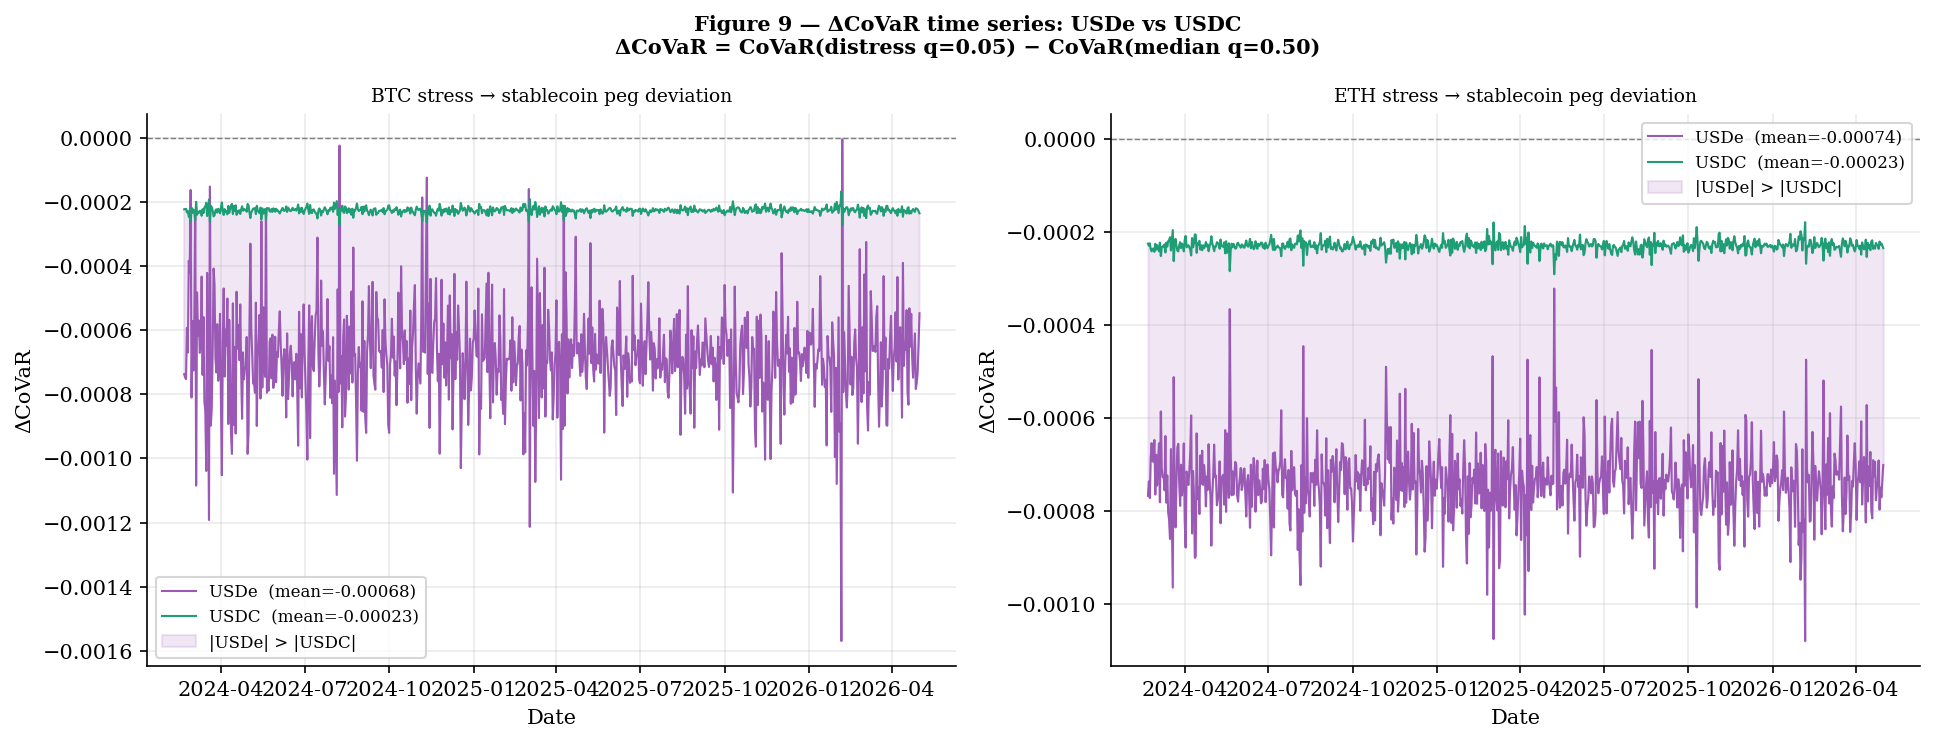

Saved fig09_deltacovar_timeseries.pdf


In [14]:
delta = pd.read_csv('covar_results/deltacovar_series.csv',
                    index_col='date', parse_dates=['date'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, crypto in zip(axes, ['BTC','ETH']):
    col_u = f'DCoVaR_{crypto}_USDe'
    col_c = f'DCoVaR_{crypto}_USDC'

    if col_u in delta.columns and col_c in delta.columns:
        d_u = delta[col_u]
        d_c = delta[col_c]

        ax.plot(d_u.index, d_u.values, color='#9B59B6', lw=1.0,
                label=f'USDe  (mean={d_u.mean():+.5f})')
        ax.plot(d_c.index, d_c.values, color='#1D9E75', lw=1.0,
                label=f'USDC  (mean={d_c.mean():+.5f})')
        ax.fill_between(d_u.index, d_u.values, d_c.values,
                        where=(np.abs(d_u.values) > np.abs(d_c.values)),
                        alpha=0.15, color='#9B59B6', label='|USDe| > |USDC|')
        ax.axhline(0, color='grey', lw=0.7, linestyle='--')
        ax.set_title(f'{crypto} stress → stablecoin peg deviation', fontsize=9)
        ax.set_ylabel('ΔCoVaR')
        ax.set_xlabel('Date')
        ax.legend(fontsize=8)

fig.suptitle('Figure 9 — ΔCoVaR time series: USDe vs USDC\n'
             'ΔCoVaR = CoVaR(distress q=0.05) − CoVaR(median q=0.50)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig09_deltacovar_timeseries.pdf', bbox_inches='tight')
plt.show()
print('Saved fig09_deltacovar_timeseries.pdf')

### Figure 10 — Quantile regression scatter plots
Shows the regression fit at q=0.05 (distress) and q=0.50 (median) for all four pairs.  
Steeper slope at q=0.05 vs q=0.50 for USDe = relationship strengthens in the tail.

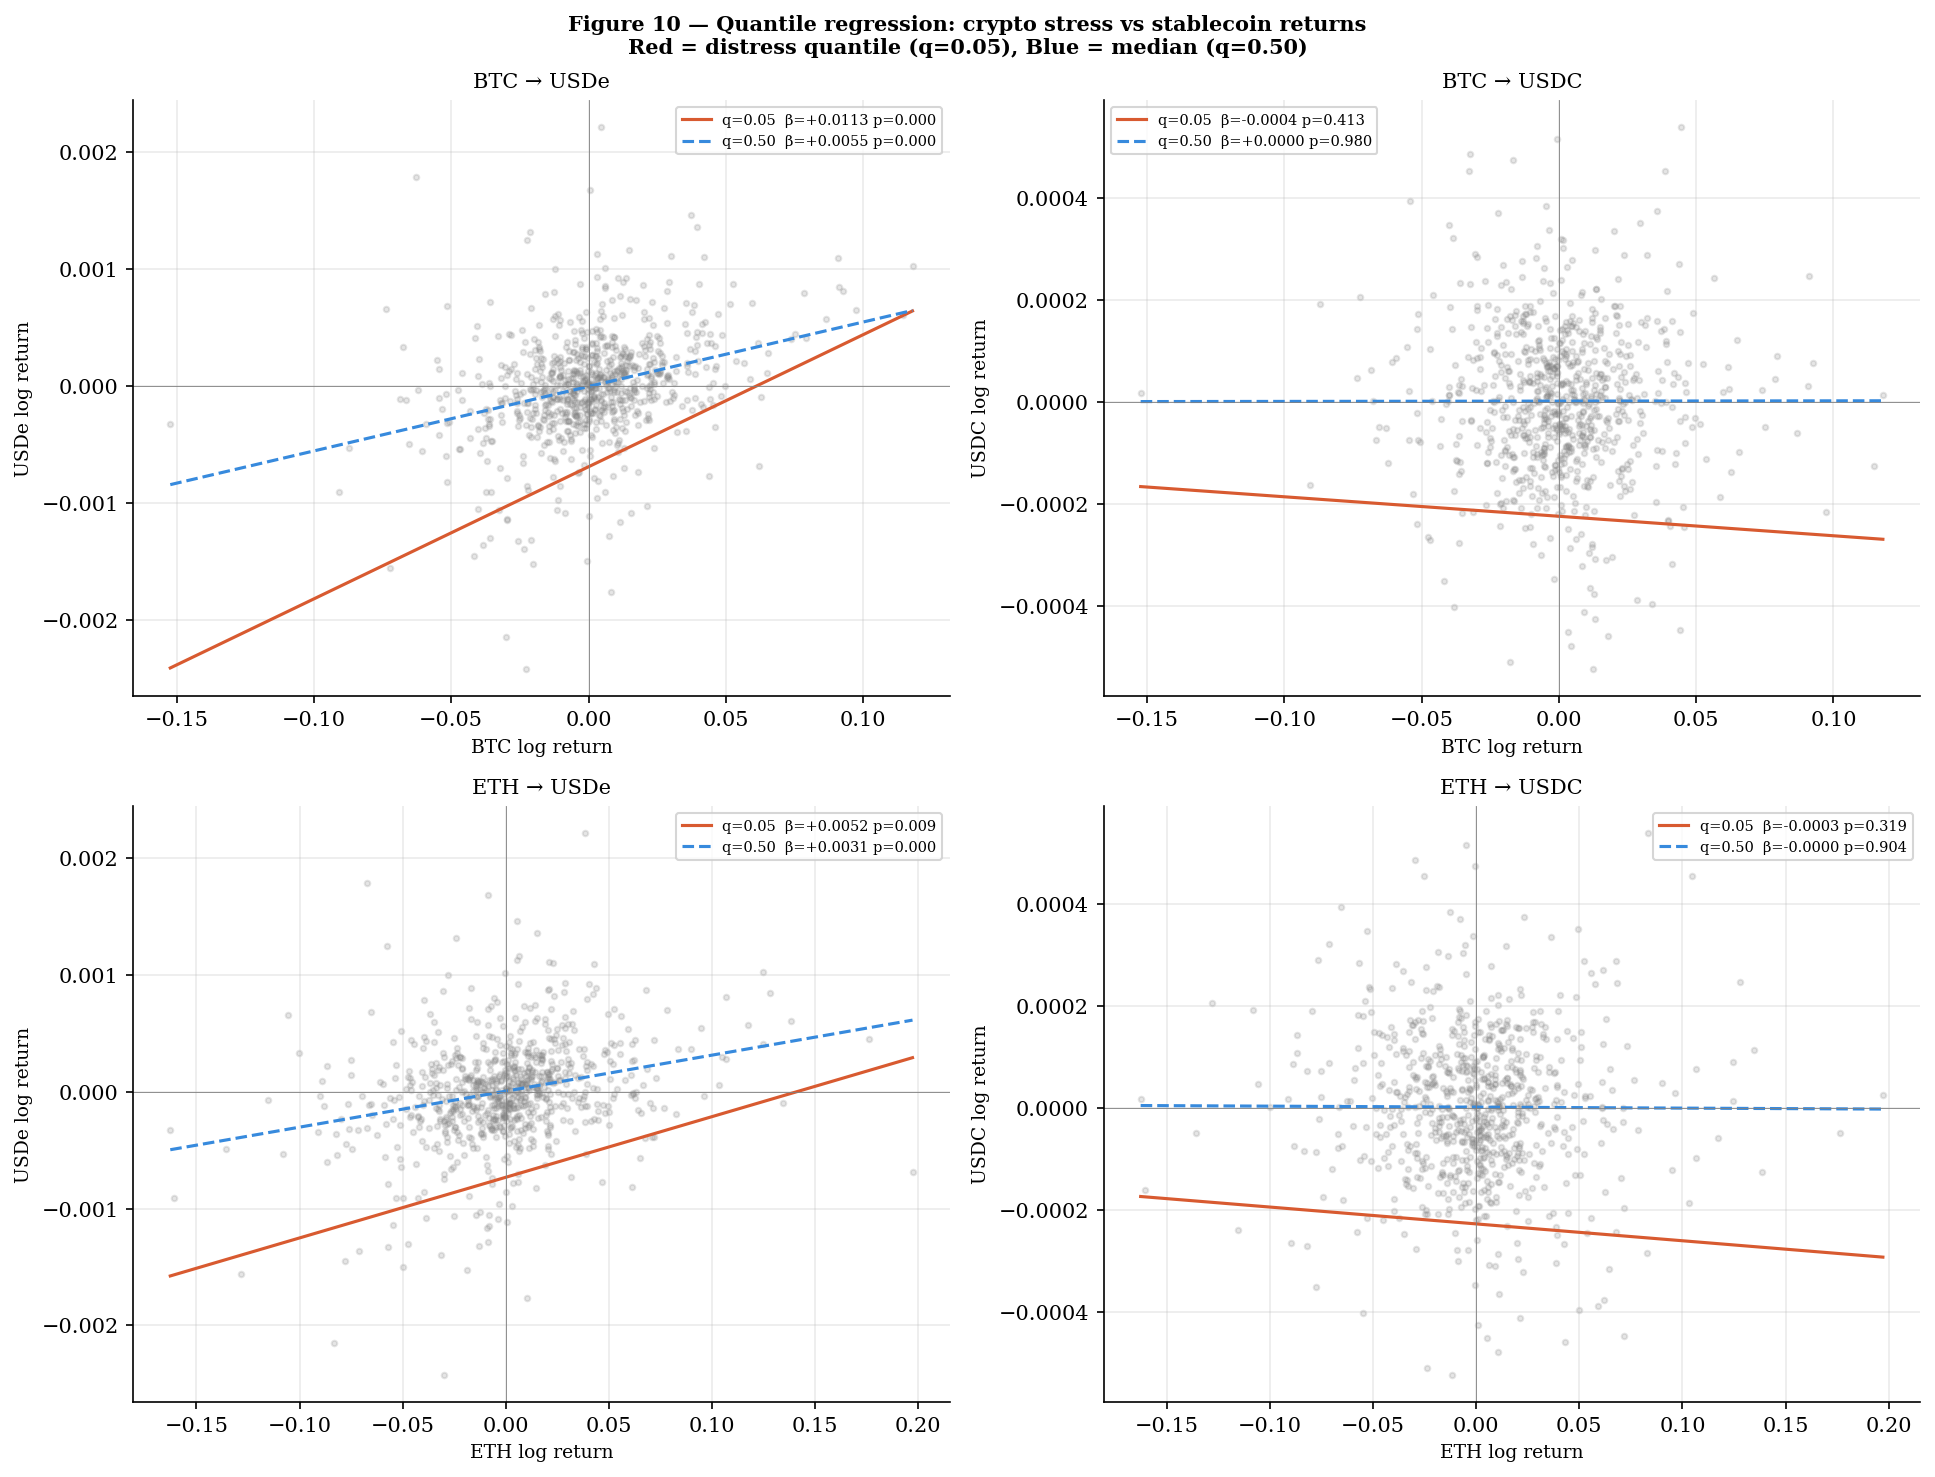

Saved fig10_quantile_scatter.pdf


In [15]:
PAIRS = [('BTC','USDe'),('BTC','USDC'),('ETH','USDe'),('ETH','USDC')]
Q_DIST, Q_MED = 0.05, 0.50

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (crypto, stable) in zip(axes, PAIRS):
    x = lr[crypto].values
    y = lr[stable].values
    X = np.column_stack([np.ones(len(x)), x])

    r05 = QuantReg(y, X).fit(q=Q_DIST, vcov='iid')
    r50 = QuantReg(y, X).fit(q=Q_MED,  vcov='iid')

    # Scatter
    ax.scatter(x, y, alpha=0.2, s=7, color='grey')

    # Regression lines
    x_line = np.linspace(x.min(), x.max(), 200)
    for res, color, label, ls in [
        (r05, '#D85A30', f'q=0.05  β={r05.params[1]:+.4f} p={r05.pvalues[1]:.3f}', '-'),
        (r50, '#378ADD', f'q=0.50  β={r50.params[1]:+.4f} p={r50.pvalues[1]:.3f}', '--'),
    ]:
        fit = res.params[0] + res.params[1] * x_line
        ax.plot(x_line, fit, color=color, lw=1.5,
                linestyle=ls, label=label)

    ax.axhline(0, color='grey', lw=0.4)
    ax.axvline(0, color='grey', lw=0.4)
    ax.set_title(f'{crypto} → {stable}', fontsize=10)
    ax.set_xlabel(f'{crypto} log return', fontsize=9)
    ax.set_ylabel(f'{stable} log return', fontsize=9)
    ax.legend(fontsize=7)

fig.suptitle('Figure 10 — Quantile regression: crypto stress vs stablecoin returns\n'
             'Red = distress quantile (q=0.05), Blue = median (q=0.50)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_quantile_scatter.pdf', bbox_inches='tight')
plt.show()
print('Saved fig10_quantile_scatter.pdf')

---
## Section 9 — Robustness Checks
### Table 12 — Alternative quantile robustness
Source: `covar_results/robustness_quantiles.csv`  
Verifies |ΔCoVaR(USDe)| > |ΔCoVaR(USDC)| holds at q=0.01, 0.05, 0.10.

In [16]:
rob_q = pd.read_csv('covar_results/robustness_quantiles.csv')

# Pivot: rows = pair, cols = quantile, values = mean ΔCoVaR
pivot12 = rob_q.pivot_table(
    index='pair', columns='q_distress',
    values='mean_deltacovar'
).round(6)
pivot12.columns = [f'q={q}' for q in pivot12.columns]

# Add CI significance marker
sig_map = rob_q.groupby(['pair','q_distress'])['significant'].first().unstack()
sig_map.columns = [f'sig_q={q}' for q in sig_map.columns]

table12 = pivot12.join(sig_map)

print('Table 12 — Robustness: Alternative Distress Quantiles')
print('Values = mean ΔCoVaR  |  sig = True if bootstrap 95% CI excludes zero')
print('=' * 65)
display(table12)

# Ranking check summary
print('\nRanking check: |ΔCoVaR(USDe)| > |ΔCoVaR(USDC)| at all quantiles')
for q in [0.01, 0.05, 0.10]:
    sub = rob_q[rob_q['q_distress']==q]
    for crypto in ['BTC','ETH']:
        u = abs(sub[(sub.crypto==crypto)&(sub.stable=='USDe')]['mean_deltacovar'].values[0])
        c = abs(sub[(sub.crypto==crypto)&(sub.stable=='USDC')]['mean_deltacovar'].values[0])
        print(f'  q={q}  {crypto}: USDe={u:.6f}  USDC={c:.6f}  '
              f'{"holds" if u>c else "FAILS"}')

print('\nLaTeX code:')
print(pivot12.to_latex(
    caption='Robustness check: mean \\Delta CoVaR across alternative distress quantiles. The ranking |\\Delta CoVaR(USDe)| > |\\Delta CoVaR(USDC)| holds at all quantiles tested.',
    label='tab:robustness_quantiles'))

Table 12 — Robustness: Alternative Distress Quantiles
Values = mean ΔCoVaR  |  sig = True if bootstrap 95% CI excludes zero


,q=0.01,q=0.05,q=0.1,sig_q=0.01,sig_q=0.05,sig_q=0.1
pair,,,,,,
BTC→USDC,-0.000400,-0.000226,-0.000174,True,True,True
BTC→USDe,-0.001212,-0.000685,-0.000430,True,True,True
ETH→USDC,-0.000402,-0.000229,-0.000174,True,True,True
ETH→USDe,-0.001244,-0.000738,-0.000447,True,True,True



Ranking check: |ΔCoVaR(USDe)| > |ΔCoVaR(USDC)| at all quantiles
  q=0.01  BTC: USDe=0.001212  USDC=0.000400  holds
  q=0.01  ETH: USDe=0.001244  USDC=0.000402  holds
  q=0.05  BTC: USDe=0.000685  USDC=0.000226  holds
  q=0.05  ETH: USDe=0.000738  USDC=0.000229  holds
  q=0.1  BTC: USDe=0.000430  USDC=0.000174  holds
  q=0.1  ETH: USDe=0.000447  USDC=0.000174  holds

LaTeX code:
\begin{table}
\caption{Robustness check: mean \Delta CoVaR across alternative distress quantiles. The ranking |\Delta CoVaR(USDe)| > |\Delta CoVaR(USDC)| holds at all quantiles tested.}
\label{tab:robustness_quantiles}
\begin{tabular}{lrrr}
\toprule
 & q=0.01 & q=0.05 & q=0.1 \\
pair &  &  &  \\
\midrule
BTC→USDC & -0.000400 & -0.000226 & -0.000174 \\
BTC→USDe & -0.001212 & -0.000685 & -0.000430 \\
ETH→USDC & -0.000402 & -0.000229 & -0.000174 \\
ETH→USDe & -0.001244 & -0.000738 & -0.000447 \\
\bottomrule
\end{tabular}
\end{table}



### Table 13 — Sub-sample stability
Source: `covar_results/robustness_subsample.csv`  
Verifies USDe > USDC result holds in both Period 1 and Period 2.

In [17]:
rob_s = pd.read_csv('covar_results/robustness_subsample.csv')

# Clean period labels for display
rob_s['period_short'] = rob_s['period'].str.extract(r'(Period \d)')

pivot13 = rob_s.pivot_table(
    index='pair', columns='period_short',
    values='mean_deltacovar'
).round(6)

sig13 = rob_s.pivot_table(
    index='pair', columns='period_short',
    values='significant'
)
sig13.columns = [f'{c} sig' for c in sig13.columns]

table13 = pivot13.join(sig13)

print('Table 13 — Sub-sample Stability Check')
print('Values = mean ΔCoVaR at q=0.05  |  sig = bootstrap CI excludes zero')

# Print period dates
periods = rob_s['period'].unique()
for p in periods:
    n = int(rob_s[rob_s['period']==p]['n'].iloc[0])
    print(f'  {p}  N={n}')
print('=' * 65)
display(table13)

print('\nLaTeX code:')
print(pivot13.to_latex(
    caption='Sub-sample stability of \\Delta CoVaR estimates (q=0.05). Sample split at midpoint. * denotes bootstrap 95\\% CI excludes zero.',
    label='tab:robustness_subsample'))

Table 13 — Sub-sample Stability Check
Values = mean ΔCoVaR at q=0.05  |  sig = bootstrap CI excludes zero
  Period 1 (2024-02-21 – 2025-03-27)  N=400
  Period 2 (2025-03-27 – 2026-05-01)  N=401


,Period 1,Period 2,Period 1 sig,Period 2 sig
pair,,,,
BTC→USDC,-0.000213,-0.000264,1.000000,1.000000
BTC→USDe,-0.000847,-0.000418,1.000000,1.000000
ETH→USDC,-0.000216,-0.000261,1.000000,1.000000
ETH→USDe,-0.000940,-0.000414,1.000000,1.000000



LaTeX code:
\begin{table}
\caption{Sub-sample stability of \Delta CoVaR estimates (q=0.05). Sample split at midpoint. * denotes bootstrap 95\% CI excludes zero.}
\label{tab:robustness_subsample}
\begin{tabular}{lrr}
\toprule
period_short & Period 1 & Period 2 \\
pair &  &  \\
\midrule
BTC→USDC & -0.000213 & -0.000264 \\
BTC→USDe & -0.000847 & -0.000418 \\
ETH→USDC & -0.000216 & -0.000261 \\
ETH→USDe & -0.000940 & -0.000414 \\
\bottomrule
\end{tabular}
\end{table}



### Figure 11 — Rolling ΔCoVaR plots
Already saved by `robustness_rolling.py`. Loaded and displayed here for the notebook record.

Figure 11 (BTC) — Rolling 120-day ΔCoVaR


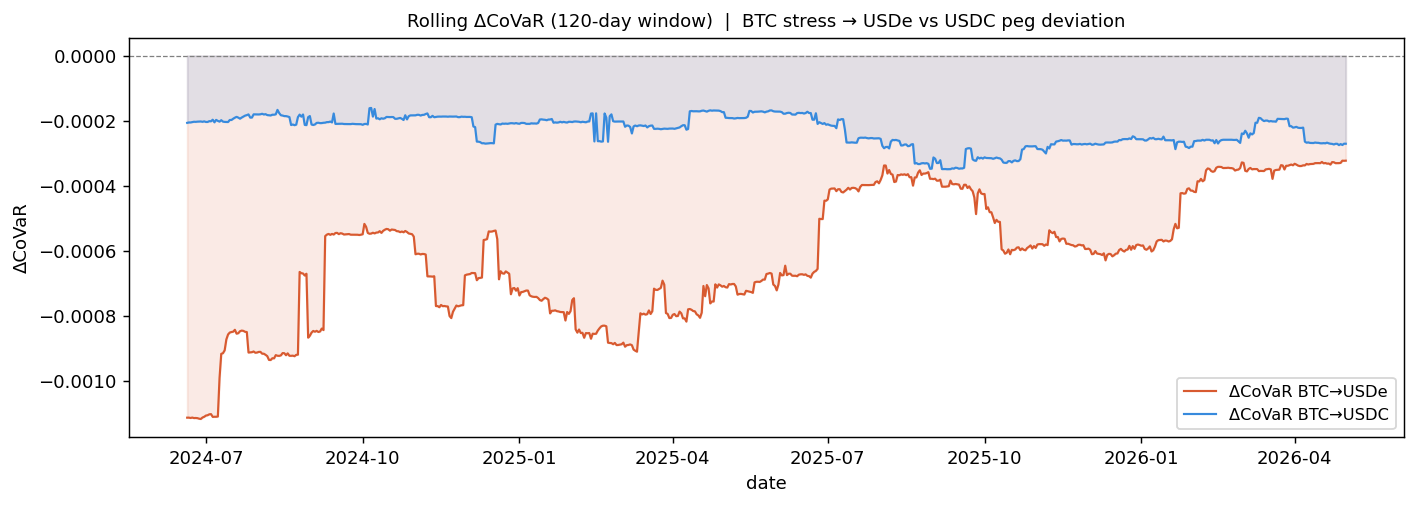

Figure 11 (ETH) — Rolling 120-day ΔCoVaR


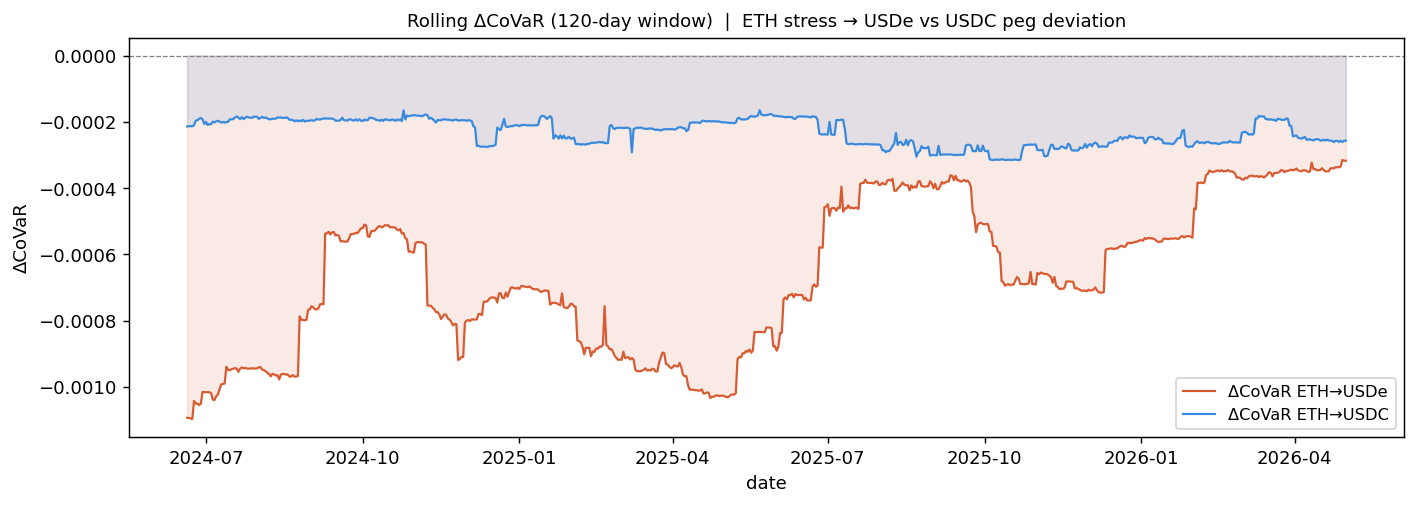

In [18]:
from IPython.display import Image, display as ipy_display
import os

for crypto in ['BTC','ETH']:
    path = f'covar_results/plots/rolling_deltacovar_{crypto}.png'
    if os.path.exists(path):
        print(f'Figure 11 ({crypto}) — Rolling 120-day ΔCoVaR')
        ipy_display(Image(filename=path, width=900))
    else:
        print(f'Run robustness_rolling.py first to generate {path}')

### Figure 12 — Absolute returns |r_t| Granger robustness
Tests BTC→USDe significance using |r_t| as alternative volatility proxy to r²_t.  
If both proxies give consistent results, the finding is robust to functional form choice.

VAR lag for |r_t|: p = 1  (BIC)

Figure 12 — Granger robustness: |r_t| vs r²_t (key directions)


,direction,p_abs_ret,sig_abs,p_r2,sig_r2
0,BTC→USDe,0.057900,False,0.019700,True
1,BTC→USDC,0.436400,False,0.649000,False
2,ETH→USDe,0.497300,False,0.220800,False
3,ETH→USDC,0.965200,False,0.721600,False


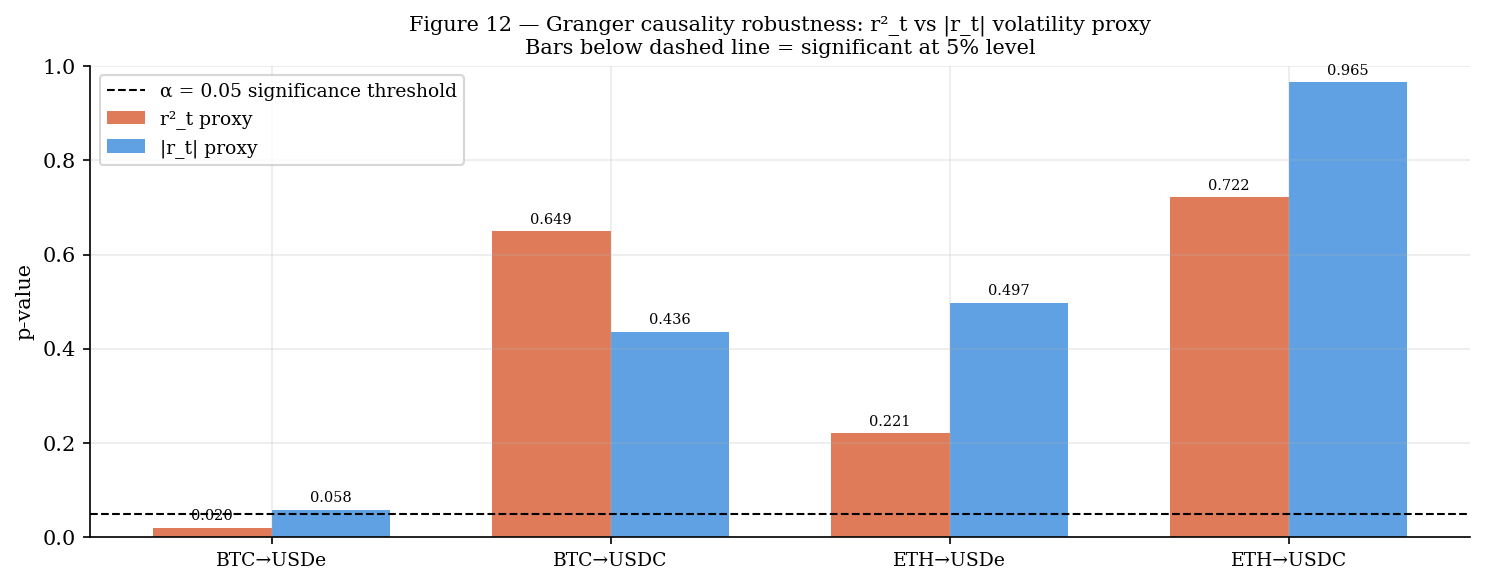

Saved fig12_granger_robustness.pdf


In [19]:
# Compute |r_t| for all assets
abs_ret = lr.abs()
abs_ret.columns = ASSETS

MAX_LAGS = 10
ALPHA    = 0.05
PAIRS_G  = [('BTC','USDe'),('BTC','USDC'),('ETH','USDe'),('ETH','USDC')]

# Lag selection for |r_t|
lag_rows = []
for p in range(1, MAX_LAGS+1):
    try:
        res = VAR(abs_ret).fit(maxlags=p, ic=None, trend='c')
        lag_rows.append({'lag':p,'BIC':res.bic})
    except Exception:
        continue
P_abs = int(pd.DataFrame(lag_rows).set_index('lag')['BIC'].idxmin())
print(f'VAR lag for |r_t|: p = {P_abs}  (BIC)')

fitted_abs = VAR(abs_ret).fit(maxlags=P_abs, ic=None, trend='c')

# Collect p-values for key directions
rows_abs = []
for crypto, stable in PAIRS_G:
    test  = fitted_abs.test_causality(caused=stable, causing=crypto, kind='f')
    rows_abs.append({
        'direction': f'{crypto}→{stable}',
        'p_abs_ret': round(float(test.pvalue), 4),
        'sig_abs':   float(test.pvalue) < ALPHA
    })

# Load r² results for comparison
r2_res = pd.read_csv('dcc_results/granger_volatility_r2.csv')
r2_key = r2_res[
    r2_res['causing'].isin(['BTC','ETH']) &
    r2_res['caused'].isin(['USDe','USDC'])
][['direction','p_value','significant']].rename(
    columns={'p_value':'p_r2','significant':'sig_r2'})

comp12 = pd.DataFrame(rows_abs).merge(r2_key, on='direction')
print('\nFigure 12 — Granger robustness: |r_t| vs r²_t (key directions)')
print('=' * 60)
display(comp12)

# Bar chart of p-values
fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(len(comp12))
width  = 0.35

bars1 = ax.bar(x - width/2, comp12['p_r2'],    width, label='r²_t proxy',
               color='#D85A30', alpha=0.8)
bars2 = ax.bar(x + width/2, comp12['p_abs_ret'], width, label='|r_t| proxy',
               color='#378ADD', alpha=0.8)

ax.axhline(ALPHA, color='black', lw=1.0, linestyle='--',
           label=f'α = {ALPHA} significance threshold')
ax.set_xticks(x)
ax.set_xticklabels(comp12['direction'], fontsize=9)
ax.set_ylabel('p-value')
ax.set_title('Figure 12 — Granger causality robustness: r²_t vs |r_t| volatility proxy\n'
             'Bars below dashed line = significant at 5% level', fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0, min(1.0, comp12[['p_r2','p_abs_ret']].max().max() + 0.15))

# Add p-value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('fig12_granger_robustness.pdf', bbox_inches='tight')
plt.show()
print('Saved fig12_granger_robustness.pdf')